## Problem Statement
You are provided with a dataset containing various attributes of different wine samples. The goal of this assignment is to perform cluster analysis using the K-means algorithm to identify natural groupings in the data based on the attributes provided.

## Dataset Overview
The dataset consists of the following columns:
1. **Alcohol**: Alcohol content in the wine sample.
2. **Malic_Acid**: Amount of malic acid in the wine.
3. **Ash**: Ash content in the wine.
4. **Ash_Alcalinity**: Alkalinity of ash in the wine.
5. **Magnesium**: Magnesium content in the wine.
6. **Total_Phenols**: Total phenols content in the wine.
7. **Flavanoids**: Flavonoid content in the wine.
8. **Nonflavanoid_Phenols**: Non-flavonoid phenol content in the wine.
9. **Proanthocyanins**: Proanthocyanin content in the wine.
10. **Color_Intensity**: Intensity of the color of the wine.
11. **Hue**: Hue of the wine.
12. **OD280**: Ratio of OD280/OD315 of diluted wines.
13. **Proline**: Proline content in the wine.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('WineData.csv')
df.head()

,Unnamed: 0,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Tasks

### Task 1: Data Preprocessing
- Handle any missing values if present.
- Scale the data using `StandardScaler` or `MinMaxScaler` since K-means is sensitive to the scale of features.
- Remove any unnecessary columns that don't contribute to clustering (e.g., index column if not relevant).

In [3]:
df.isnull().sum()

Unnamed: 0              0
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [4]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
from sklearn.preprocessing import StandardScaler


In [6]:
scaler = StandardScaler()

In [7]:
X_scaled = scaler.fit_transform(df)

In [8]:
df1 = df.copy()

### Task 2: Determine the Optimal Number of Clusters
- Use the **Elbow method** to determine the optimal number of clusters.
- Visualize the results using a line plot of the **Within-Cluster Sum of Squares (WCSS)** against the number of clusters.



In [9]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [10]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k, init = 'k-means++',random_state = 33)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[2314.0,
 1659.9511977619795,
 1282.4635183465311,
 1205.1325367766262,
 1116.1609159150753,
 1066.0010798295696,
 1018.6936010660829,
 959.7012543254133,
 908.4132836433496,
 902.7734169745305]

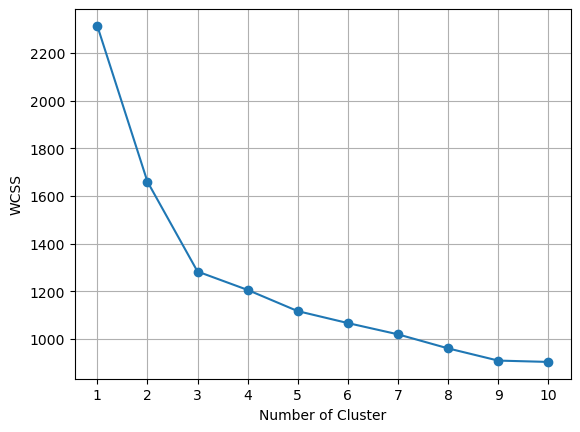

In [12]:
plt.plot(range(1,11),wcss, marker = 'o')
plt.xticks(range(1,11))
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Task 3: K-means Clustering
- Apply K-means clustering using the optimal number of clusters obtained from the Elbow method.
- Assign cluster labels to each data point and create a new column in the dataset with these labels.



In [13]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++',random_state = 33)
df['Cluster_Labels'] = kmeans.fit_predict(X_scaled)

In [14]:
df.sample(5)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Cluster_Labels
45,14.21,4.04,2.44,18.9,111,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080,0
88,11.64,2.06,2.46,21.6,84,1.95,1.69,0.48,1.35,2.80,1.00,2.75,680,1
93,12.29,2.83,2.22,18.0,88,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290,1
169,13.40,4.60,2.86,25.0,112,1.98,0.96,0.27,1.11,8.50,0.67,1.92,630,2
158,14.34,1.68,2.70,25.0,98,2.80,1.31,0.53,2.70,13.00,0.57,1.96,660,2


### Task 4: Cluster Analysis
- Analyze the clusters by comparing the mean values of each feature within each cluster.
- Visualize the clusters using a pairplot or scatterplot for selected features to understand the separations visually.



In [15]:
cluster_means = df.groupby('Cluster_Labels').mean()
cluster_means

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
Cluster_Labels,,,,,,,,,,,,,
0,13.592388,1.936119,2.442985,17.594030,108.298507,2.838060,2.956418,0.286269,1.938806,5.305373,1.071493,3.142836,1069.223881
1,12.241774,1.972097,2.230000,20.012903,91.064516,2.195968,2.000484,0.373226,1.553065,2.984839,1.048806,2.765968,492.887097
2,13.151633,3.344490,2.434694,21.438776,99.020408,1.678163,0.797959,0.450816,1.163061,7.343265,0.685918,1.690204,627.551020


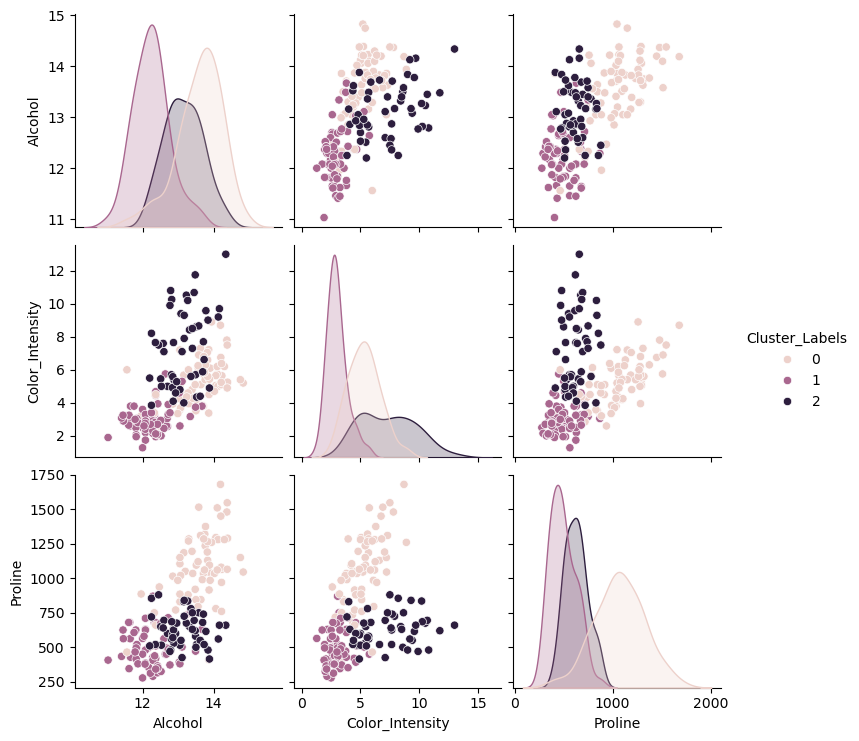

In [16]:
import seaborn as sns
sns.pairplot(df[['Alcohol','Color_Intensity','Proline','Cluster_Labels']], hue = 'Cluster_Labels')
plt.show()

### Task 5: Interpretation
- Interpret the characteristics of each cluster. For example, identify which cluster has the highest alcohol content, or which has the most intense color, etc.
- Suggest potential names or categories for each cluster based on the observed characteristics.


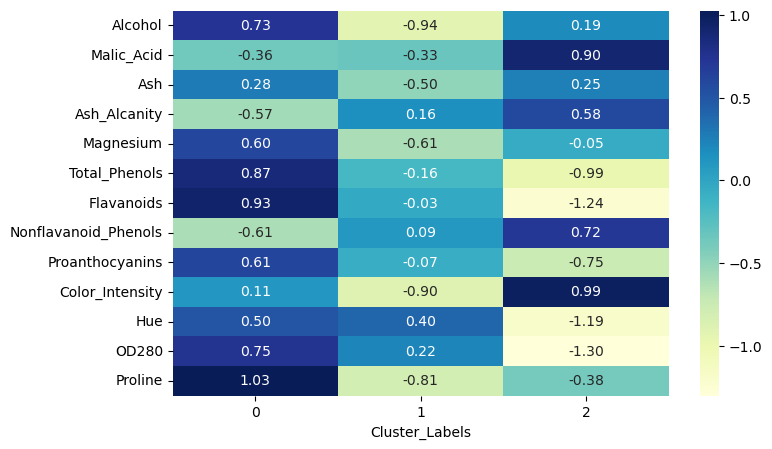

In [17]:
plt.figure(figsize = (8,5))
scaled_df = pd.DataFrame(X_scaled, columns=df1.columns)
scaled_df['Cluster_Labels'] = df['Cluster_Labels']
cluster_scaled_mean = scaled_df.groupby('Cluster_Labels').mean()
sns.heatmap(cluster_scaled_mean.T, annot=True, cmap='YlGnBu', fmt=".2f")
plt.show()

- **Cluster 0: High Quality / Rich Wine**
  - Features:
    - Alcohol: High
    - Proline: High
    - Magnesium: High
    - Total Phenols & Flavanoids: High
    - Color Intensity: Medium
  - Interpretation: These wines are balanced, strong in flavor, and can be considered premium-quality wines.

- **Cluster 1: Light / Mild Wines**
  - Features:
    - Alcohol: Low
    - Proline: Low
    - Magnesium: Low
    - Color Intensity: Low
    - Total Phenols & Flavanoids: Medium to Low
  - Interpretation: These wines are lighter in body, smoother, and have mild flavor profiles.

- **Cluster 2: High Color / Sharp Wines**
  - Features:
    - Color Intensity: High
    - Malic Acid: High
    - Ash Alcanity: High
    - Nonflavanoid Phenols: High
    - Total Phenols & Flavanoids: Low
  - Interpretation: Wines in this cluster have intense color but comparatively less phenolic content, giving them sharper taste profiles.

**Overall Summary:**
- Cluster 0: Premium, balanced wines  
- Cluster 1: Light-bodied, mild wines  
- Cluster 2: Dark-colored, sharper wines